# **1. 드라이브 연결**

In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

Mounted at /content/drive


# **2. 전처리 및 데이터셋 분할**

In [2]:
# ==========================================
# 1. 라이브러리 및 환경 설정
# ==========================================
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix, f1_score
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")


# ==========================================
# 2. 데이터 로드
# ==========================================
file_path = "/content/drive/MyDrive/ASK_2026_FDC/Dataset/MACHINE_Data.xlsx"

if os.path.exists(file_path):
    print(f"Loading data from: {file_path}")
    if file_path.endswith('.xlsx'):
        df = pd.read_excel(file_path)
    else:
        df = pd.read_csv(file_path)
else:
    print("파일을 찾을 수 없습니다. 경로를 확인해주세요.")
    df = pd.DataFrame()

# 센서 컬럼 정의
sensor_cols = [
    'BCl3 Flow', 'Cl2 Flow', 'RF Btm Pwr', 'RF Btm Rfl Pwr', 'Endpt A',
    'He Press', 'Pressure', 'RF Tuner', 'RF Load', 'RF Phase Err',
    'RF Pwr', 'RF Impedance', 'TCP Tuner', 'TCP Phase Err',
    'TCP Impedance', 'TCP Top Pwr', 'TCP Rfl Pwr', 'TCP Load', 'Vat Valve'
]

# ==========================================
# 3. 데이터 전처리 함수
# ==========================================
"""
    Wafer_ID 별로 슬라이딩 윈도우를 적용하고,
    각 윈도우가 어떤 Wafer에 속하는지 ID 리스트를 함께 반환합니다.
"""
def create_sequences_with_ids(df_target, wafer_col, sensor_cols, seq_len, scaler=None, is_train=True):

    # 1. 데이터 추출
    data_values = df_target[sensor_cols].values

    # 2. 스케일링 (Train 통계로만 Scale)
    if is_train:
        if scaler is None:
            scaler = MinMaxScaler()
        data_scaled = scaler.fit_transform(data_values)
    else:
        if scaler is None:
            raise ValueError("Test mode requires a fitted scaler from training data.")
        data_scaled = scaler.transform(data_values)

    # 스케일링된 데이터를 다시 DataFrame으로 매핑 (ID 그룹핑 용도)
    df_scaled = pd.DataFrame(data_scaled, columns=sensor_cols, index=df_target.index)
    df_scaled[wafer_col] = df_target[wafer_col].values

    all_sequences = []
    all_wafer_ids = [] # [NEW] 각 윈도우의 소스 Wafer ID를 저장할 리스트

    unique_wafers = df_scaled[wafer_col].unique()

    for wafer in unique_wafers:
        # 특정 Wafer 데이터 추출
        wafer_data = df_scaled[df_scaled[wafer_col] == wafer][sensor_cols].values

        # 데이터 길이가 윈도우보다 작으면 스킵
        if len(wafer_data) < seq_len:
            continue

        # 슬라이딩 윈도우 생성
        for i in range(len(wafer_data) - seq_len + 1):
            window = wafer_data[i : i + seq_len]

            all_sequences.append(window)
            all_wafer_ids.append(wafer) # [NEW] 현재 윈도우의 Wafer ID 저장

    if len(all_sequences) == 0:
        return np.array([]), np.array([]), scaler

    return np.array(all_sequences), np.array(all_wafer_ids), scaler

# ==========================================
# 4. 데이터셋 구성 및 저장
# ==========================================
experiments = ['l29', 'l31', 'l33']     # 실험 별 구분
datasets = {}
SEQ_LEN = 32      # 슬라이딩 윈도우 파라미터

# 학습 데이터 비율 설정
TRAIN_RATIO = 0.6

if 'global_eval_results' not in globals():
    global_eval_results = {}

print(f"\n--- Preprocessing Data (Train Ratio: {TRAIN_RATIO*100}%) ---")

for exp_id in experiments:
    print(f"\nProcessing Experiment: {exp_id}")

    # 1. 실험 데이터 필터링
    exp_df = df[df['Wafer_ID'].str.contains(exp_id, case=False, na=False)]
    if exp_df.empty:
        continue

    # 2. Train / Test Split (Wafer ID 기준)
    normal_wafer_ids = exp_df[exp_df['Label'] == 'Normal']['Wafer_ID'].unique()
    fault_wafer_ids = exp_df[exp_df['Label'] == 'Fault']['Wafer_ID'].unique()

    # [수정] 비율 적용 (Normal Wafer만 분할)
    n_train = int(len(normal_wafer_ids) * TRAIN_RATIO)

    train_ids = normal_wafer_ids[:n_train]
    test_norm_ids = normal_wafer_ids[n_train:]

    # ID 기반 데이터프레임 분할
    train_df = exp_df[exp_df['Wafer_ID'].isin(train_ids)]
    test_norm_df = exp_df[exp_df['Wafer_ID'].isin(test_norm_ids)]
    test_fault_df = exp_df[exp_df['Wafer_ID'].isin(fault_wafer_ids)]

    print(f"  - Total Normal: {len(normal_wafer_ids)}")
    print(f"  -> Train Normal : {len(train_ids)} ({TRAIN_RATIO*100:.0f}%)")
    print(f"  -> Test Normal  : {len(test_norm_ids)} ({(1-TRAIN_RATIO)*100:.0f}%)")
    print(f"  -> Test Fault   : {len(fault_wafer_ids)} (100%)")

    # 3. 시퀀스 생성 (X, Wafer_ID 반환)
    # (1) Train: Scaler 학습 (Fit)
    X_train, y_train_ids, scaler = create_sequences_with_ids(
        train_df, 'Wafer_ID', sensor_cols, SEQ_LEN, scaler=None, is_train=True
    )

    # (2) Test Normal: Scaler 적용 (Transform)
    X_test_norm, y_test_norm_ids, _ = create_sequences_with_ids(
        test_norm_df, 'Wafer_ID', sensor_cols, SEQ_LEN, scaler=scaler, is_train=False
    )

    # (3) Test Fault: Scaler 적용 (Transform)
    if not test_fault_df.empty:
        X_test_fault, y_test_fault_ids, _ = create_sequences_with_ids(
            test_fault_df, 'Wafer_ID', sensor_cols, SEQ_LEN, scaler=scaler, is_train=False
        )
    else:
        X_test_fault, y_test_fault_ids = np.array([]), np.array([])

    # 4. Dictionary에 저장
    datasets[exp_id] = {
        'X_train': X_train,
        'X_test_norm': X_test_norm,
        'X_test_fault': X_test_fault,
        'ids_train': y_train_ids,
        'ids_test_norm': y_test_norm_ids,
        'ids_test_fault': y_test_fault_ids,
        'scaler': scaler
    }

print("\n✅ Data preprocessing with new ratio completed.")

✅ Using device: cuda
Loading data from: /content/drive/MyDrive/ASK_2026_FDC/Dataset/MACHINE_Data.xlsx

--- Preprocessing Data (Train Ratio: 60.0%) ---

Processing Experiment: l29
  - Total Normal: 34
  -> Train Normal : 20 (60%)
  -> Test Normal  : 14 (40%)
  -> Test Fault   : 9 (100%)

Processing Experiment: l31
  - Total Normal: 37
  -> Train Normal : 22 (60%)
  -> Test Normal  : 15 (40%)
  -> Test Fault   : 6 (100%)

Processing Experiment: l33
  - Total Normal: 37
  -> Train Normal : 22 (60%)
  -> Test Normal  : 15 (40%)
  -> Test Fault   : 6 (100%)

✅ Data preprocessing with new ratio completed.


# **3. 함수 정의**

In [3]:
# ==========================================
# 3. 공통 함수
# ==========================================
def get_data_loaders(exp_id, datasets_dict, batch_size=32):
    print(f"\n📊 [Data Setup] Experiment: {exp_id}")
    data = datasets_dict[exp_id]

    # 데이터 추출
    X_train = data['X_train']
    X_test_norm = data['X_test_norm']
    ids_test_norm = data['ids_test_norm']
    X_test_fault = data['X_test_fault']
    ids_test_fault = data['ids_test_fault']

    # Tensor 변환
    train_tensor = torch.FloatTensor(X_train)
    test_norm_tensor = torch.FloatTensor(X_test_norm)

    if len(X_test_fault) > 0:
        test_fault_tensor = torch.FloatTensor(X_test_fault)
    else:
        test_fault_tensor = torch.FloatTensor([])

    # DataLoader (Train only)
    train_loader = DataLoader(TensorDataset(train_tensor), batch_size=batch_size, shuffle=True)

    return train_loader, (test_norm_tensor, ids_test_norm), (test_fault_tensor, ids_test_fault)

def aggregate_wafer_scores(window_scores, wafer_ids, method='max'):
    # DataFrame핑하여 GroupBy 연산
    df_temp = pd.DataFrame({'Wafer_ID': wafer_ids, 'Score': window_scores})

    if method == 'max':
        grouped = df_temp.groupby('Wafer_ID')['Score'].max()
    else:
        grouped = df_temp.groupby('Wafer_ID')['Score'].mean()

    return grouped.index.values, grouped.values

def evaluate_performance_fixed_threshold(model_name, exp_id, scores, labels, threshold):
    # 1. 고정된 임계값을 기준으로 이상 여부 판별 (크면 1: Fault, 작으면 0: Normal)
    preds = (scores > threshold).astype(int)

    # 2. F1-Score 계산 (더 이상 최적의 값을 찾지 않음)
    f1 = f1_score(labels, preds)

    # 3. AUROC 계산 (AUC는 임계값과 무관하게 모델의 분류 잠재력을 보여줌)
    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)

    print(f"\n📌 [{model_name} - {exp_id}] Wafer-Level Summary (Unsupervised)")
    print(f"   - AUROC          : {roc_auc:.4f}")
    print(f"   - F1-Score       : {f1:.4f} (at Fixed Threshold: {threshold:.6f})")

    # --- 👇 전역 딕셔너리에 결과 저장 추가 부분 👇 ---
    if model_name not in global_eval_results:
        global_eval_results[model_name] = {}

    global_eval_results[model_name][exp_id] = {
        'AUC': roc_auc,
        'F1-Score': f1,
        'FPR': fpr,
        'TPR': tpr
    }

    # 시각화 함수 호출
    visualize_results(model_name, exp_id, scores, labels, threshold)

    return roc_auc, f1

def visualize_results(model_name, exp_id, scores, labels, threshold):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    plt.suptitle(f"[{exp_id}] {model_name} Performance (Wafer-Level)", fontsize=16, fontweight='bold')

    # Confusion Matrix
    preds = (scores > threshold).astype(int)
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
                xticklabels=['Normal', 'Fault'], yticklabels=['Normal', 'Fault'])
    axes[0].set_title("Confusion Matrix")

    # Scatter Plot (Wafer Scores)
    normal_idx = np.where(labels == 0)[0]
    fault_idx = np.where(labels == 1)[0]

    axes[1].scatter(normal_idx, scores[normal_idx], color='blue', label='Normal', alpha=0.6, s=20)
    axes[1].scatter(fault_idx, scores[fault_idx], color='red', label='Fault', alpha=0.6, s=20)
    axes[1].axhline(y=threshold, color='green', linestyle='--', label='Threshold')
    axes[1].set_title("Wafer Anomaly Scores")
    axes[1].legend()

    # ROC Curve
    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)
    axes[2].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
    axes[2].plot([0, 1], [0, 1], color='navy', linestyle='--')
    axes[2].set_title("ROC Curve")
    axes[2].legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# **4. 모델 구현 및 학습**

In [4]:
# ==========================================
# [Cell 2] 실험별 모델 학습 및 비지도 임계값 산출
# ==========================================
target_experiments = ['l29', 'l31', 'l33']

if 'trained_artifacts' not in globals():
    trained_artifacts = {}


# 1. 공통 하이퍼파라미터
BATCH_SIZE = 32
NUM_EPOCHS = 50
LEARNING_RATE = 0.001
CALIBRATION_WINDOW = 10
SIGMA_MULTIPLIER = 3

In [5]:
# CasualConv1d layer
# 과거-현재 데이터만 보고 특징을 추출함
class CausalConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation=1):
        super(CausalConv1d, self).__init__()
        self.padding = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size,
                              padding=self.padding, dilation=dilation)

    def forward(self, x):
        x = self.conv(x)
        return x[:, :, :-self.padding]

class TemporalConvNet(nn.Module):
    def __init__(self, num_inputs, num_channels, kernel_size=3, dropout=0.2):
        super(TemporalConvNet, self).__init__()
        layers = []
        num_levels = len(num_channels)
        for i in range(num_levels):
            dilation_size = 2 ** i
            in_channels = num_inputs if i == 0 else num_channels[i-1]
            out_channels = num_channels[i]
            layers += [
                CausalConv1d(in_channels, out_channels, kernel_size, dilation=dilation_size),
                nn.ReLU(),
                nn.Dropout(dropout)
            ]
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

class TRACE_GPT(nn.Module):
    def __init__(self, num_sensors, seq_len, d_model=128, n_head=8, num_layers=6, resolution=100, dropout=0.1):
        super(TRACE_GPT, self).__init__()
        self.num_sensors = num_sensors
        self.seq_len = seq_len
        self.resolution = resolution
        self.d_model = d_model

        # TCN 4층 (Receptive Field 확보)
        tcn_channels = [d_model] * 4

        self.tcn = TemporalConvNet(
            num_inputs=num_sensors + 1, # +1 for Time Index
            num_channels=tcn_channels,
            kernel_size=3,
            dropout=dropout
        )

        self.transformer_encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=d_model, nhead=n_head, batch_first=True, dropout=dropout),
            num_layers=num_layers
        )

        self.output_head = nn.Linear(d_model, num_sensors * resolution)

    def _generate_square_subsequent_mask(self, sz):
        mask = (torch.triu(torch.ones(sz, sz)) == 1).transpose(0, 1)
        mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
        return mask

    def forward(self, x):
        batch_size, curr_seq_len, _ = x.size()

        # Positional Embedding
        steps = torch.arange(curr_seq_len, device=x.device, dtype=torch.float32)
        time_idx = (steps / self.seq_len).unsqueeze(0).unsqueeze(2)
        time_idx = time_idx.expand(batch_size, -1, -1)

        x_emb = torch.cat([x, time_idx], dim=2)

        x_tcn = x_emb.permute(0, 2, 1)
        x_tcn = self.tcn(x_tcn)
        x_tcn = x_tcn.permute(0, 2, 1)

        tgt_mask = self._generate_square_subsequent_mask(curr_seq_len).to(x.device)
        output = self.transformer_encoder(x_tcn, mask=tgt_mask, is_causal=True)

        logits = self.output_head(output)
        logits = logits.view(batch_size, curr_seq_len, self.num_sensors, self.resolution)

        return logits


# 변환 함수
# 0~1 사이의 실수 데이터를 0~99 사이의 정수 데이터로 변환
def quantize_data(x, resolution=100):
    x_idx = (x * (resolution - 1)).long()
    x_idx = torch.clamp(x_idx, 0, resolution - 1)
    return x_idx


# 학습 함수
def train_trace_gpt(model, train_loader, optimizer, epoch, device, resolution=100):
    model.train()
    total_loss = 0
    criterion = nn.CrossEntropyLoss()

    for (data,) in train_loader:
        data = data.to(device)
        optimizer.zero_grad()

        # Input(0~T-1) -> Target(1~T): 데이터 분할
        input_seq = data[:, :-1, :]
        target_seq = data[:, 1:, :]
        target_idx = quantize_data(target_seq, resolution)

        output_logits = model(input_seq)

        # loss 계산 (모델의 예측과 실제 정답 간의 차이)
        loss = criterion(
            output_logits.reshape(-1, resolution),
            target_idx.reshape(-1)
        )
        # 가중치 업데이트
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    if (epoch + 1) % 10 == 0: # 10 epoch마다 로그 출력
        print(f"Epoch [{epoch+1}] Loss: {avg_loss:.4f}")
    return avg_loss

def trace_calculate_window_scores(model, data_tensor, device, batch_size=32, resolution=100):
    model.eval()
    all_scores = []
    criterion = nn.CrossEntropyLoss(reduction='none')   # loss 계산

    dataset = TensorDataset(data_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    with torch.no_grad():
        for (data,) in loader:
            data = data.to(device)
            input_seq = data[:, :-1, :]   # 입력 데이터
            target_seq = data[:, 1:, :]   # 정답 데이터
            target_idx = quantize_data(target_seq, resolution)    # 정답 데이터를 0~99로 변환

            output_logits = model(input_seq)    # 모델이 예측한 확률값

            loss_element = criterion(
                output_logits.reshape(-1, resolution),
                target_idx.reshape(-1)
            )
            loss_element = loss_element.view(input_seq.shape[0], input_seq.shape[1], input_seq.shape[2])

            # Window별 평균 Loss
            score_window = loss_element.mean(dim=[1, 2])
            all_scores.extend(score_window.cpu().numpy())

    return np.array(all_scores)

In [6]:
# ==========================================
# TRACE-GPT 모델 학습
# ==========================================
m_name = "TRACE-GPT"
trace_config = {
    "d_model": 64,
    "resolution": 100
}

# 모델별 저장 공간 초기화
if m_name not in trained_artifacts:
    trained_artifacts[m_name] = {}

print(f"\n🚀 Phase 1: Training [{m_name}] on Experiments: {target_experiments}")

for exp_id in target_experiments:
    if exp_id not in datasets:
        print(f"Skipping {exp_id}: Dataset not found.")
        continue

    print(f"\n" + "-"*40)
    print(f" 🏭 Training on Experiment: {exp_id}")
    print("-"*40)

    # 데이터 로드 (각 실험별 Train Data)
    train_loader, _, _ = get_data_loaders(exp_id, datasets, BATCH_SIZE)
    num_sensors = train_loader.dataset.tensors[0].shape[2]
    seq_len_input = train_loader.dataset.tensors[0].shape[1]

    # 모델 객체 독립적 초기화
    model = TRACE_GPT(
        num_sensors=num_sensors,
        seq_len=seq_len_input - 1,
        d_model=trace_config["d_model"],
        resolution=trace_config["resolution"]
    ).to(device)
    # 가중치: Adam
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # 모델 학습
    for epoch in range(NUM_EPOCHS):
        train_trace_gpt(model, train_loader, optimizer, epoch, device, trace_config["resolution"])

    # 비지도 학습 임계값 계산 (해당 실험 Train 데이터 기준)
    print(f"Calculating Train Scores for Thresholding")
    train_tensor = train_loader.dataset.tensors[0]

    # 학습 데이터의 점수 계산
    train_window_scores = trace_calculate_window_scores(model, train_tensor, device, BATCH_SIZE, trace_config["resolution"])

    ids_train = datasets[exp_id]['ids_train']
    # 각 Window의 이상 점수를 Wafer 단위로 집계
    _, train_wafer_scores = aggregate_wafer_scores(train_window_scores, ids_train, method='max')

    # Threshold 산출
    train_mean = np.mean(train_wafer_scores)    # 평균 계산
    train_std = np.std(train_wafer_scores)      # 표준편차 계산
    fixed_threshold = train_mean + (SIGMA_MULTIPLIER * train_std)   # 3-Sigma 범위 안에서 threshold 산출

    print(f"   * Train Score Mean: {train_mean:.4f}, Std: {train_std:.4f}")
    print(f"   * Fixed {SIGMA_MULTIPLIER}-Sigma Threshold: {fixed_threshold:.4f}")

    # 전역 딕셔너리에 실험별로 안전하게 저장
    trained_artifacts[m_name][exp_id] = {
        'model': model,
        'threshold': fixed_threshold,
        'config': trace_config
    }

print(f"\n✅ [{m_name}] successfully trained and saved for all experiments.")


🚀 Phase 1: Training [TRACE-GPT] on Experiments: ['l29', 'l31', 'l33']

----------------------------------------
 🏭 Training on Experiment: l29
----------------------------------------

📊 [Data Setup] Experiment: l29
Epoch [10] Loss: 2.3197
Epoch [20] Loss: 2.1953
Epoch [30] Loss: 2.1147
Epoch [40] Loss: 2.0413
Epoch [50] Loss: 1.9703
Calculating Train Scores for Thresholding
   * Train Score Mean: 2.1449, Std: 0.0462
   * Fixed 3-Sigma Threshold: 2.2835

----------------------------------------
 🏭 Training on Experiment: l31
----------------------------------------

📊 [Data Setup] Experiment: l31
Epoch [10] Loss: 2.1822
Epoch [20] Loss: 2.0518
Epoch [30] Loss: 1.9717
Epoch [40] Loss: 1.8787
Epoch [50] Loss: 1.7820
Calculating Train Scores for Thresholding
   * Train Score Mean: 2.0292, Std: 0.0763
   * Fixed 3-Sigma Threshold: 2.2582

----------------------------------------
 🏭 Training on Experiment: l33
----------------------------------------

📊 [Data Setup] Experiment: l33
Epoch [

# **5. 모델 저장**

In [7]:
import os
import torch
import pickle

save_dir = "/content/drive/MyDrive/ASK_2026_FDC/Code/최종 코드/Saved"
os.makedirs(save_dir, exist_ok=True)

m_name = "TRACE-GPT"

print(f"\n 모델 및 메타데이터 저장")

# 학습된 모든 실험군('l29', 'l31', 'l33' 등)에 대해 저장 진행
for exp_id in target_experiments:
    if m_name in trained_artifacts and exp_id in trained_artifacts[m_name]:

        # 1. 학습된 모델, Config, 임계값 가져오기
        saved_model = trained_artifacts[m_name][exp_id]['model']
        config = trained_artifacts[m_name][exp_id]['config']

        # 2. Threshold 보정 (테스트셋의 정상 데이터 사용)
        print(f"  [{exp_id}] Threshold 보정 중...")
        X_test_norm = datasets[exp_id]['X_test_norm']
        ids_test_norm = datasets[exp_id]['ids_test_norm']

        # 정상 테스트 데이터 평가
        test_norm_tensor = torch.FloatTensor(X_test_norm).to(device)
        norm_window_scores = trace_calculate_window_scores(saved_model, test_norm_tensor, device, batch_size=32, resolution=config['resolution'])

        # 웨이퍼 단위로 점수 집계
        df_temp = pd.DataFrame({'Wafer_ID': ids_test_norm, 'Score': norm_window_scores})
        norm_wafer_scores = df_temp.groupby('Wafer_ID')['Score'].max().values

        # 처음 10개(CALIBRATION_WINDOW)의 정상 웨이퍼로 새로운 기준점 산출
        CALIBRATION_WINDOW = 10
        if len(norm_wafer_scores) >= CALIBRATION_WINDOW:
            cal_mean = np.mean(norm_wafer_scores[:CALIBRATION_WINDOW])
            cal_std = np.std(norm_wafer_scores[:CALIBRATION_WINDOW])
            # 보정된 임계값 덮어쓰기!
            final_threshold = cal_mean + (3 * cal_std)
            print(f"  ▶ 보정된 임계값 적용 완료: {final_threshold:.4f}")
        else:
            final_threshold = trained_artifacts[m_name][exp_id]['threshold'] # 데이터 부족 시 기존 값 사용
            print("  ▶ 데이터 부족으로 Train 임계값 유지")

        # 3. PyTorch 모델 가중치(Weight) 저장 (*.pth)
        model_path = f"{save_dir}/trace_gpt_{exp_id}.pth"
        torch.save(saved_model.state_dict(), model_path)

        # 4. 데이터셋 및 추론용 정보 묶어서 저장 (*.pkl)
        metadata = {
            "config": config,
            "threshold": final_threshold,
            "sensor_cols": sensor_cols,
            "scaler": datasets[exp_id].get('scaler', None),
            "X_test_norm": datasets[exp_id]['X_test_norm'],
            "ids_test_norm": datasets[exp_id]['ids_test_norm'],
            "X_test_fault": datasets[exp_id]['X_test_fault'],
            "ids_test_fault": datasets[exp_id]['ids_test_fault']
        }

        meta_path = f"{save_dir}/metadata_{exp_id}.pkl"
        with open(meta_path, 'wb') as f:
            pickle.dump(metadata, f)

        print(f"  ✅ [{exp_id}] 모델 저장 완료: {model_path}")
    else:
        print(f"  ❌ [{exp_id}] 저장 실패: 학습된 모델이 없습니다.")



 모델 및 메타데이터 저장
  [l29] Threshold 보정 중...
  ▶ 보정된 임계값 적용 완료: 3.1763
  ✅ [l29] 모델 저장 완료: /content/drive/MyDrive/ASK_2026_FDC/Code/최종 코드/Saved/trace_gpt_l29.pth
  [l31] Threshold 보정 중...
  ▶ 보정된 임계값 적용 완료: 3.2888
  ✅ [l31] 모델 저장 완료: /content/drive/MyDrive/ASK_2026_FDC/Code/최종 코드/Saved/trace_gpt_l31.pth
  [l33] Threshold 보정 중...
  ▶ 보정된 임계값 적용 완료: 3.0942
  ✅ [l33] 모델 저장 완료: /content/drive/MyDrive/ASK_2026_FDC/Code/최종 코드/Saved/trace_gpt_l33.pth


# **6. 모델 추론**


🔍 Phase 2: Evaluating [TRACE-GPT] on Experiments: ['l29', 'l31', 'l33']

 📊 Evaluating Experiment: l29
Calculating Test Window Scores...
Aggregating Test Wafer Scores...

📌 [TRACE-GPT - l29] Wafer-Level Summary (Unsupervised)
   - AUROC          : 1.0000
   - F1-Score       : 0.9474 (at Fixed Threshold: 3.094231)


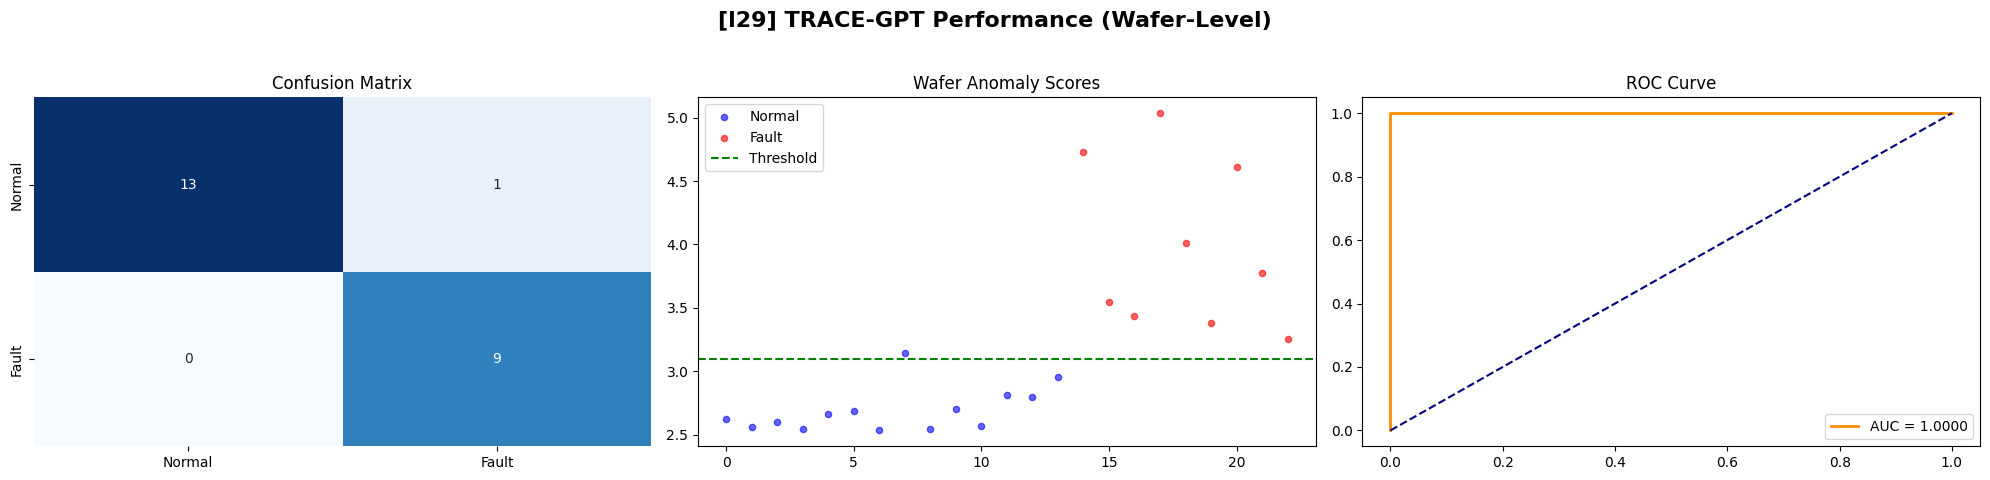


 📊 Evaluating Experiment: l31
Calculating Test Window Scores...
Aggregating Test Wafer Scores...

📌 [TRACE-GPT - l31] Wafer-Level Summary (Unsupervised)
   - AUROC          : 1.0000
   - F1-Score       : 0.8571 (at Fixed Threshold: 3.094231)


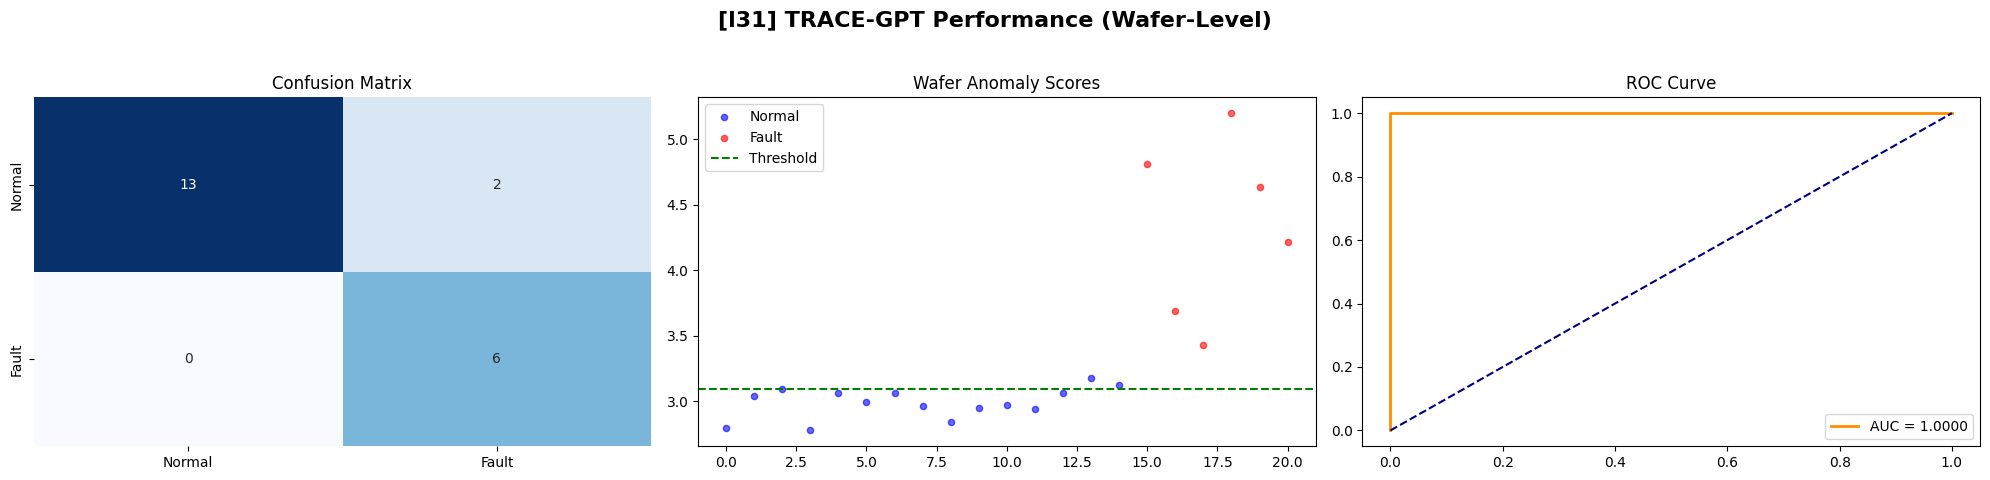


 📊 Evaluating Experiment: l33
Calculating Test Window Scores...
Aggregating Test Wafer Scores...

📌 [TRACE-GPT - l33] Wafer-Level Summary (Unsupervised)
   - AUROC          : 1.0000
   - F1-Score       : 0.9231 (at Fixed Threshold: 3.094231)


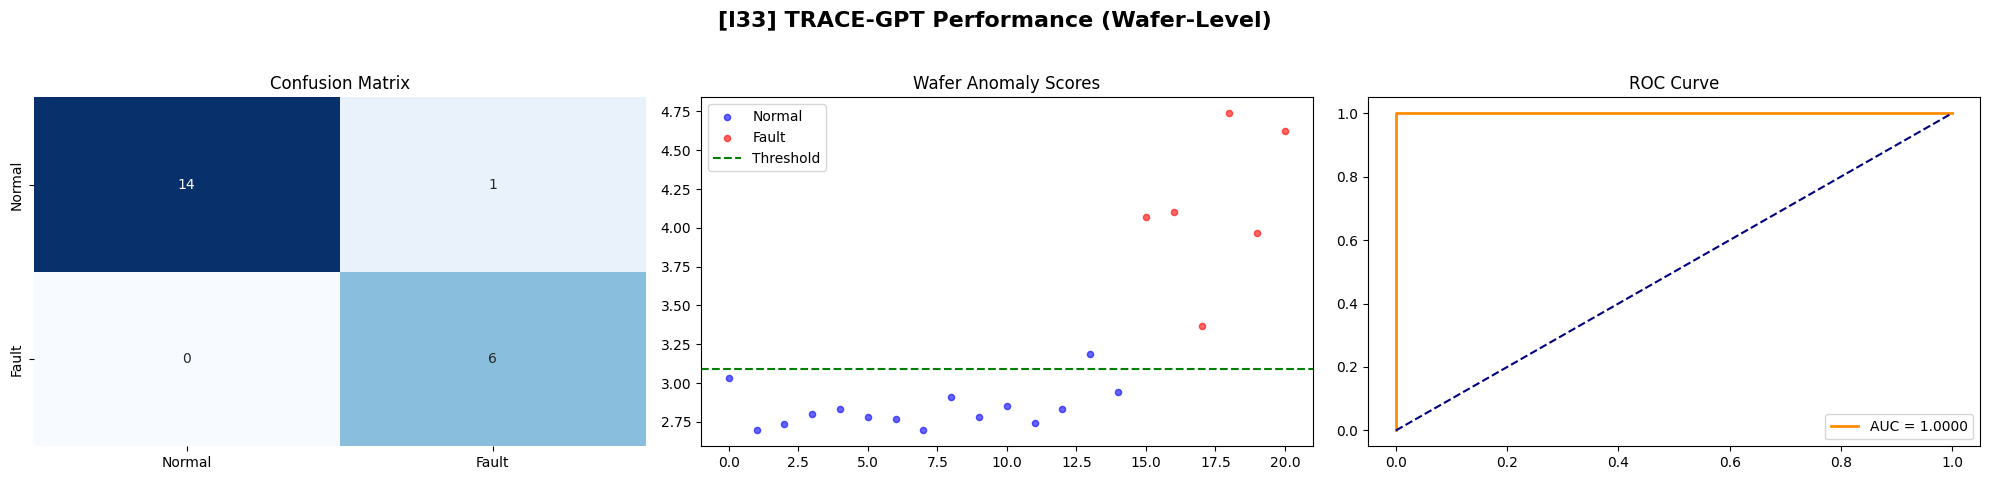

In [8]:
# ==========================================
# 실험별 모델 추론 및 시각화
# ==========================================
target_experiments = ['l29', 'l31', 'l33']
BATCH_SIZE = 32

m_name = "TRACE-GPT"

if m_name not in trained_artifacts:
    print(f"❌ Error: Model '{m_name}' is not trained yet.")
else:
    print(f"\n🔍 Phase 2: Evaluating [{m_name}] on Experiments: {target_experiments}")

    for exp_id in target_experiments:
        if exp_id not in trained_artifacts[m_name]:
            print(f"Skipping {exp_id}: No trained model found.")
            continue

        print(f"\n" + "="*50)
        print(f" 📊 Evaluating Experiment: {exp_id}")
        print("="*50)

        # 저장된 객체 및 고유 변수 불러오기
        saved_model = trained_artifacts[m_name][exp_id]['model']
        fixed_threshold = trained_artifacts[m_name][exp_id]['threshold']
        config = trained_artifacts[m_name][exp_id]['config']

        # 해당 실험의 Test Data 로드
        data = datasets[exp_id]
        test_norm = torch.FloatTensor(data['X_test_norm']).to(device)

        if len(data['X_test_fault']) > 0:
            test_fault = torch.FloatTensor(data['X_test_fault']).to(device)
        else:
            test_fault = torch.FloatTensor([]).to(device)

        ids_norm = data['ids_test_norm']
        ids_fault = data['ids_test_fault']

        # 추론 수행 (Test Data 전용)
        print("Calculating Test Window Scores...")
        norm_window_scores = trace_calculate_window_scores(saved_model, test_norm, device, BATCH_SIZE, config["resolution"])
        if len(test_fault) > 0:
            fault_window_scores = trace_calculate_window_scores(saved_model, test_fault, device, BATCH_SIZE, config["resolution"])
        else:
            fault_window_scores = np.array([])

        # Wafer 단위 집계
        print("Aggregating Test Wafer Scores...")
        _, norm_wafer_scores = aggregate_wafer_scores(norm_window_scores, ids_norm, method='max')
        norm_labels = np.zeros(len(norm_wafer_scores))

        if len(fault_window_scores) > 0:
            _, fault_wafer_scores = aggregate_wafer_scores(fault_window_scores, ids_fault, method='max')
            fault_labels = np.ones(len(fault_wafer_scores))
        else:
            fault_wafer_scores = np.array([])
            fault_labels = np.array([])

        final_scores = np.concatenate([norm_wafer_scores, fault_wafer_scores])
        final_labels = np.concatenate([norm_labels, fault_labels])

        # 5. 평가 및 시각화
        if len(np.unique(final_labels)) > 1:
            auc_score, f1 = evaluate_performance_fixed_threshold(
                m_name, exp_id, final_scores, final_labels, final_threshold
            )